In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load our engineered master dataset
df = pd.read_csv(r'C:\Users\varsh\Downloads\Real estate prediction model\data\processed\bengaluru_house_data_engineered.csv')

# Define macro-economic variables for Bengaluru real estate forecasting
BASE_REAL_ESTATE_CAGR = 0.065  # 6.5% standard annual organic property appreciation
INFLATION_RATE = 0.052         # 5.2% projected baseline inflation rate
COMBINED_GROWTH_RATE = BASE_REAL_ESTATE_CAGR + (INFLATION_RATE * 0.25) # Risk-adjusted baseline multiplier

print(f"Forecasting engine calibrated at a baseline compounding rate of: {COMBINED_GROWTH_RATE*100:.1f}% per annum.")

Forecasting engine calibrated at a baseline compounding rate of: 7.8% per annum.


In [2]:
# Project prices from Year 1 to Year 5
for year in range(1, 6):
    df[f'projected_price_yr_{year}'] = df['price'] * ((1 + COMBINED_GROWTH_RATE) ** year)

print("=== 5-Year Value Progression Sample (in Lakhs) ===")
print(df[['price', 'projected_price_yr_1', 'projected_price_yr_3', 'projected_price_yr_5']].head())

=== 5-Year Value Progression Sample (in Lakhs) ===
   price  projected_price_yr_1  projected_price_yr_3  projected_price_yr_5
0  150.0               161.700            187.908983            218.366022
1  149.0               160.622            186.656256            216.910249
2  150.0               161.700            187.908983            218.366022
3   44.0                47.432             55.119968             64.054033
4   40.0                43.120             50.109062             58.230939


C:\Users\varsh\AppData\Local\Temp\ipykernel_2612\2801756614.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'projected_price_yr_{year}'] = df['price'] * ((1 + COMBINED_GROWTH_RATE) ** year)


In [7]:
# Lower the strictness threshold to catch rising neighborhoods with smaller sample footprints
MIN_LISTING_THRESHOLD = 5  
PRICE_PERCENTILE_THRESHOLD = df['price'].quantile(0.45) # Captures high-affordability zones

# Re-run the aggregation
location_stats = df.groupby('location_name').agg(
    avg_price=('price', 'mean'),
    total_listings=('total_sqft', 'count'),
    city_score=('city_center_proximity_score', 'first')
).reset_index()

# Apply the broadened filter
emerging_zones = location_stats[
    (location_stats['total_listings'] >= MIN_LISTING_THRESHOLD) & 
    (location_stats['avg_price'] <= PRICE_PERCENTILE_THRESHOLD)
].sort_values(by='total_listings', ascending=False).head(10)

print("=== Top 10 High-Potential Emerging Growth Locations (Optimized) ===")
print(emerging_zones[['location_name', 'total_listings', 'avg_price']].to_string(index=False))

=== Top 10 High-Potential Emerging Growth Locations (Optimized) ===
        location_name  total_listings  avg_price
          Tumkur Road              23  60.756957
         Malleshpalya              13  59.938462
             Nagavara              12  59.065000
           Anjanapura              11  63.181818
          Yelenahalli              10  55.264000
       Prithvi Layout              10  60.566000
          Dommasandra              10  63.147000
   Pattandur Agrahara              10  64.755000
          Rajiv Nagar              10  51.916500
Banashankari Stage VI               8  60.750000


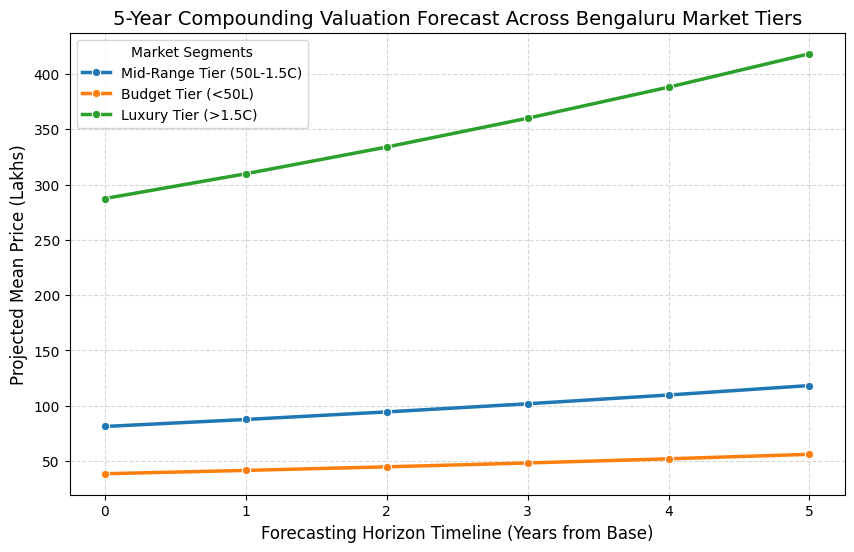

In [8]:
# Classify properties into strategic market tiers
def assign_tier(p):
    if p < 50: return 'Budget Tier (<50L)'
    elif p <= 150: return 'Mid-Range Tier (50L-1.5C)'
    else: return 'Luxury Tier (>1.5C)'

df['market_tier'] = df['price'].apply(assign_tier)

# Calculate mean projections across structural tiers
tier_trends = df.groupby('market_tier')[[f'projected_price_yr_{y}' for y in range(1, 6)]].mean()
tier_trends.insert(0, 'projected_price_yr_0', df.groupby('market_tier')['price'].mean())

# Reshape dataframe for clean time-series visualization
tier_trends_long = tier_trends.T.reset_index()
tier_trends_long['Year'] = tier_trends_long['index'].apply(lambda x: int(x.split('_')[-1]))

# Plot the progression lines
plt.figure(figsize=(10, 6))
for tier in df['market_tier'].unique():
    sns.lineplot(data=tier_trends_long, x='Year', y=tier, marker='o', linewidth=2.5, label=tier)

plt.title('5-Year Compounding Valuation Forecast Across Bengaluru Market Tiers', fontsize=14)
plt.xlabel('Forecasting Horizon Timeline (Years from Base)', fontsize=12)
plt.ylabel('Projected Mean Price (Lakhs)', fontsize=12)
plt.xticks(range(0, 6))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Market Segments")
plt.show()

In [9]:
forecast_output_path = '../data/processed/bengaluru_future_forecasts.csv'
df.to_csv(forecast_output_path, index=False)

print(f"🎉 Success! Future Price Forecasting pipeline run complete.")
print(f"Saved interactive visualization data engine to: {forecast_output_path}")

🎉 Success! Future Price Forecasting pipeline run complete.
Saved interactive visualization data engine to: ../data/processed/bengaluru_future_forecasts.csv
